<a href="https://colab.research.google.com/github/Sarthak3144/Decepticons_-Network-Graph-Intelligence/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Setting up styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
#Loading datasets
print("Loading datasets")
tx_df = pd.read_csv('transactions.csv')
accounts_df = pd.read_csv('accounts.csv')
edges_df = pd.read_csv('graph_edges.csv')
ml_features_df = pd.read_csv('ml_features.csv')
print("Loading successful")

Loading datasets
Loading successful


In [4]:
#Dataset Overview (Row, Column Counts & Data Types)
datasets = {
    "Transactions": tx_df,
    "Accounts (KYC)": accounts_df,
    "Graph Edges": edges_df,
    "ML Features": ml_features_df
}
print("Dataset Overview")


for name, df in datasets.items():
    print(f"\n{name} Dataset Details:")
    print(f"Total Rows: {df.shape[0]:,}")
    print(f"Total Columns: {df.shape[1]}")
    print("Data Types:")
    print(df.dtypes.value_counts())
    print("-" * 30)

Dataset Overview

Transactions Dataset Details:
Total Rows: 100,222
Total Columns: 55
Data Types:
int64      25
object     20
float64    10
Name: count, dtype: int64
------------------------------

Accounts (KYC) Dataset Details:
Total Rows: 65,339
Total Columns: 13
Data Types:
object    8
int64     4
bool      1
Name: count, dtype: int64
------------------------------

Graph Edges Dataset Details:
Total Rows: 100,222
Total Columns: 6
Data Types:
int64      3
object     2
float64    1
Name: count, dtype: int64
------------------------------

ML Features Dataset Details:
Total Rows: 100,222
Total Columns: 35
Data Types:
int64      25
float64     8
object      2
Name: count, dtype: int64
------------------------------


In [5]:
#Missing Value Analysis and Data Quality Check
print("Missing Value Analysis")
print("=" * 30)
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

    if not missing_df.empty:
        print(f"\nMissing data found in '{name}':")
        print(missing_df)
    else:
        print(f"\nNo missing values found in '{name}'.")

print("\nData Quality Health Check")
print("=" * 30)

# 1. Negative amounts check
neg_tx = (tx_df['amount_local_npr'] < 0).sum()
print(f"Transactions with negative NPR amounts: {neg_tx}")

# 2. Graph integrity check: Do all edge accounts exist in KYC?
edge_senders = set(edges_df['Sender_account'].unique())
edge_receivers = set(edges_df['Receiver_account'].unique())
all_edge_nodes = edge_senders.union(edge_receivers)
kyc_nodes = set(accounts_df['account_id'].unique())

missing_kyc = len(all_edge_nodes - kyc_nodes)
print(f"Active graph accounts missing from KYC registry: {missing_kyc}")

Missing Value Analysis

No missing values found in 'Transactions'.

No missing values found in 'Accounts (KYC)'.

No missing values found in 'Graph Edges'.

No missing values found in 'ML Features'.

Data Quality Health Check
Transactions with negative NPR amounts: 0
Active graph accounts missing from KYC registry: 0


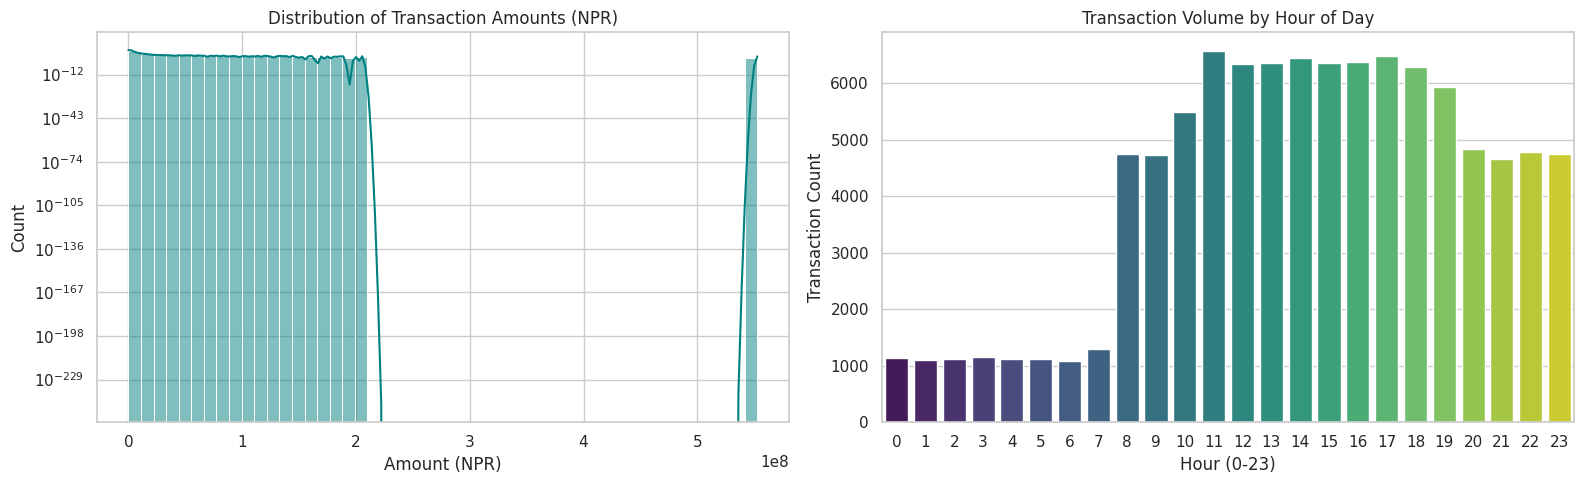

In [6]:
# Feature Distribution (Transactions Amount and Timing)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Distribution of transaction sizes
sns.histplot(tx_df['amount_local_npr'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Transaction Amounts (NPR)')
axes[0].set_xlabel('Amount (NPR)')
axes[0].set_yscale('log') # Log scale because money laundering data has extreme outliers

# Plot 2: Hourly pattern of transactions
sns.countplot(data=tx_df, x='hour_of_day', palette='viridis', ax=axes[1])
axes[1].set_title('Transaction Volume by Hour of Day')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Transaction Count')

plt.tight_layout()
plt.show()

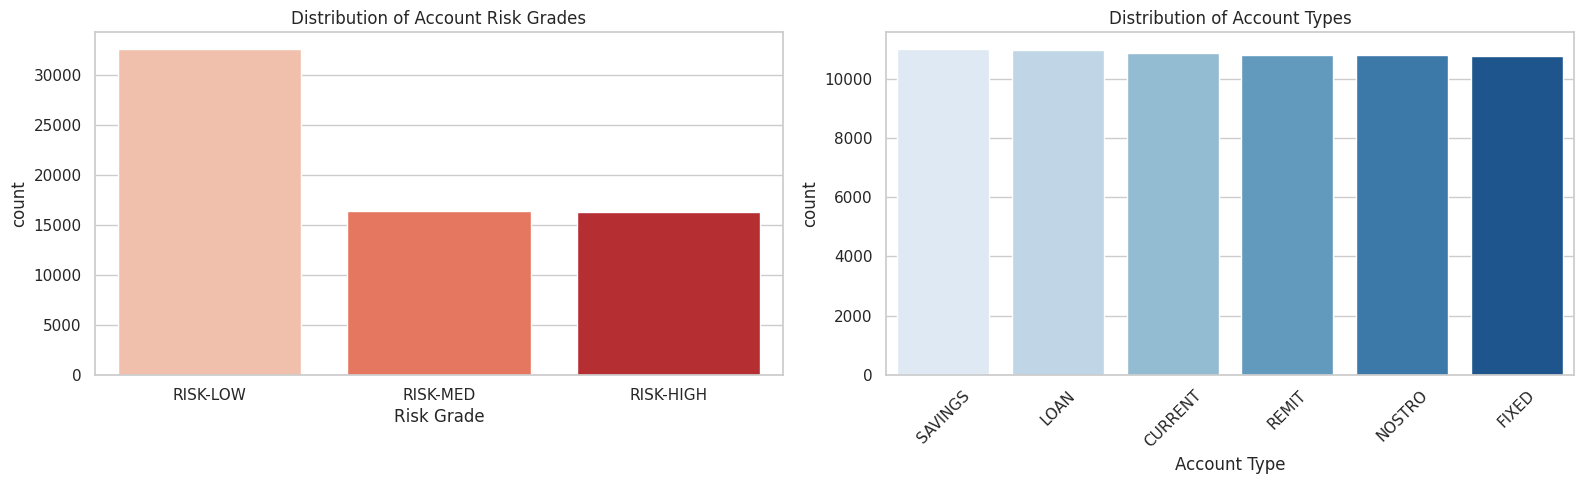

In [7]:
# Node level Distributions (Risck Grades and Account types)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Account Risk Profiles
sns.countplot(data=accounts_df, x='risk_grade', order=['RISK-LOW', 'RISK-MED', 'RISK-HIGH'], palette='Reds', ax=axes[0])
axes[0].set_title('Distribution of Account Risk Grades')
axes[0].set_xlabel('Risk Grade')

# Plot 2: Types of accounts
sns.countplot(data=accounts_df, x='acct_type', order=accounts_df['acct_type'].value_counts().index, palette='Blues', ax=axes[1])
axes[1].set_title('Distribution of Account Types')
axes[1].set_xlabel('Account Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

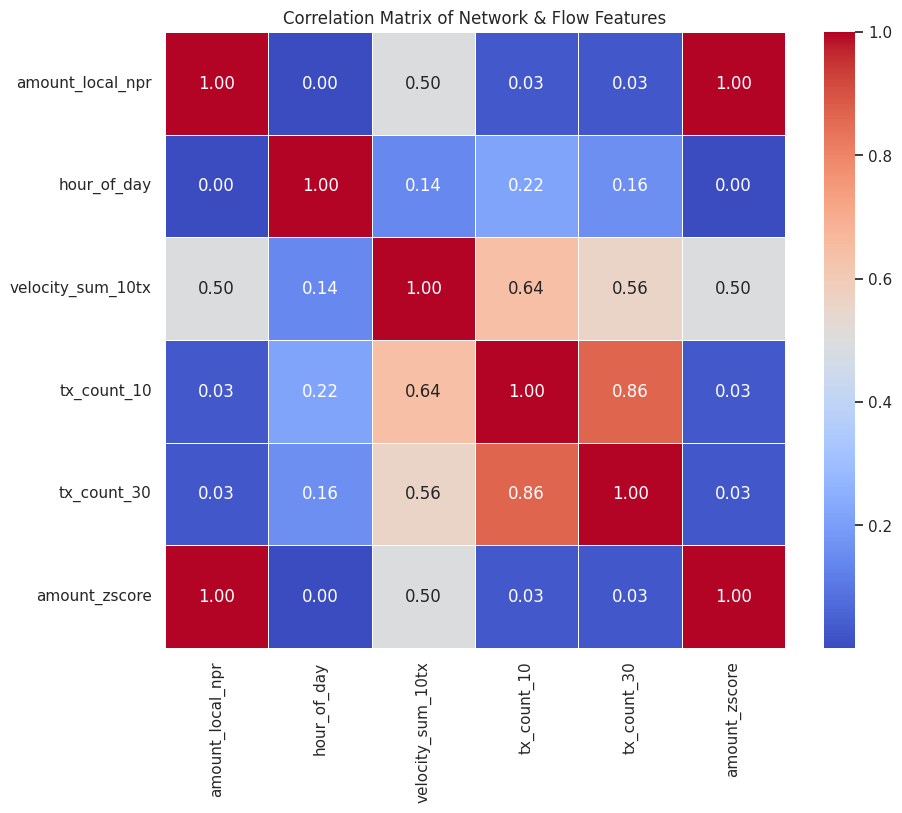

In [8]:
# Correlations and Key Feature Relationships

# Selecting numerical columns that are highly relevant to AML tracking
corr_cols = ['amount_local_npr', 'hour_of_day', 'velocity_sum_10tx', 'tx_count_10', 'tx_count_30', 'amount_zscore']

# Filtering columns that exist in the transaction dataset
existing_corr_cols = [c for c in corr_cols if c in tx_df.columns]

plt.figure(figsize=(10, 8))
corr_matrix = tx_df[existing_corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Network & Flow Features')
plt.show()

In [9]:
# Network Specific Baseline Insights

print("Baseline Graph Insights")
print("=" * 30)

# Computing basic degree distributions using pandas for quickness
send_counts = edges_df['Sender_account'].value_counts()
receive_counts = edges_df['Receiver_account'].value_counts()

print(f"Total Unique Senders: {len(send_counts):,}")
print(f"Total Unique Receivers: {len(receive_counts):,}")

print("\nTop Fan-Out Accounts (Potential Senders / Smurfing):")
print(send_counts.head(5))

print("\nTop Fan-In Accounts (Potential Receivers / Collectors):")
print(receive_counts.head(5))

# Accounts that both send and receive (Potential Layering / pass-through accounts)
layering_candidates = set(send_counts.index).intersection(set(receive_counts.index))
print(f"\nAccounts acting as both Senders & Receivers (Pass-through / Layering candidates): {len(layering_candidates):,}")

Baseline Graph Insights
Total Unique Senders: 22,310
Total Unique Receivers: 46,586

Top Fan-Out Accounts (Potential Senders / Smurfing):
Sender_account
8976725341    265
382301928     264
15297964      263
1452170043    262
7658664999    262
Name: count, dtype: int64

Top Fan-In Accounts (Potential Receivers / Collectors):
Receiver_account
6086421020    241
9683990807    241
464342049     240
7099141711    240
5251195293    240
Name: count, dtype: int64

Accounts acting as both Senders & Receivers (Pass-through / Layering candidates): 3,557


Advanced Graph Intelligence: Amount Conservation Paths
Analysis Results:
Detected 4481 instances of strict multi-hop amount conservation.
This indicates funds passed to a middleman and were subsequently swept to a third account nearly intact.

Sample High-Risk Layering Chains Found:
 Sender_account_hop1  Receiver_account_hop1  Receiver_account_hop2  amount_local_npr_hop1  amount_local_npr_hop2  amount_ratio
          9119143782             1576773608             3880609685              939592.23              895955.36      0.953558
          3139337800             8817936053             7070455925              662906.61              662906.61      1.000000
          3373148945             6034997194             9716991603             4414373.91             4491467.98      1.017464
          1805171806             1465487567             6956716334             1219913.74             1178179.13      0.965789
          3396853729             4293580479             1971949846             53

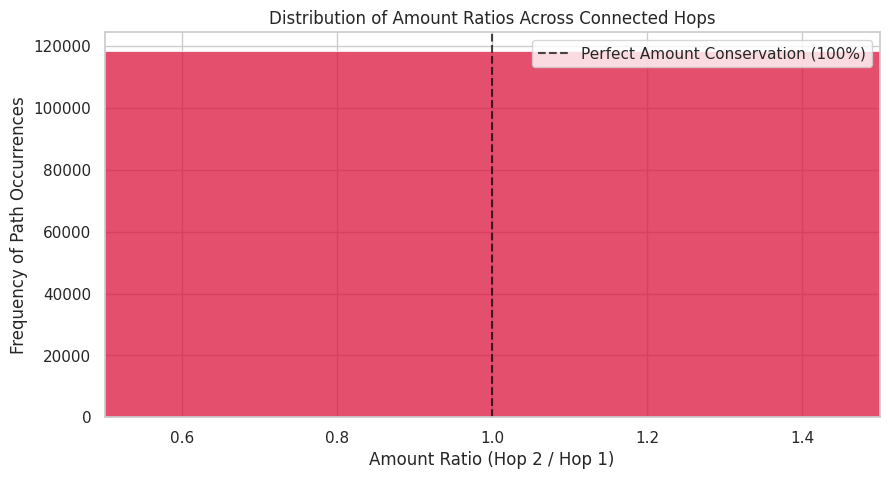

In [10]:

print("Advanced Graph Intelligence: Amount Conservation Paths")
print("=" * 50)

# We want to find cases where Account A -> Account B (Amount X) and then Account B -> Account C (Amount Y)
# where Amount Y is very close to Amount X (e.g., within 5%), indicating a layering chain.

# Step 1: Merging transactions with itself to track sequential flows from a middleman (Receiver who becomes a Sender)
flow_df = tx_df.merge(
    tx_df,
    left_on='Receiver_account',
    right_on='Sender_account',
    suffixes=('_hop1', '_hop2')
)

# Step 2: Applying Domain Rules
# Rule A: Hop 2 must happen around or after Hop 1 (sequential timing or rapid automation)
# Rule B: Amount conservation (The middleman forwards between 95% and 100% of the money to obscure trails)
flow_df['amount_ratio'] = flow_df['amount_local_npr_hop2'] / flow_df['amount_local_npr_hop1']

layering_chains = flow_df[
    (flow_df['amount_ratio'] >= 0.95) &
    (flow_df['amount_ratio'] <= 1.05) &
    (flow_df['Sender_account_hop1'] != flow_df['Receiver_account_hop2']) # Exclude simple back-and-forth pairs
]

print("Analysis Results:")
print(f"Detected {len(layering_chains)} instances of strict multi-hop amount conservation.")
print("This indicates funds passed to a middleman and were subsequently swept to a third account nearly intact.\n")

# Step 3: Displaying the top suspicious multi-hop structural paths found
if not layering_chains.empty:
    print("Sample High-Risk Layering Chains Found:")
    display_cols = ['Sender_account_hop1', 'Receiver_account_hop1', 'Receiver_account_hop2',
                    'amount_local_npr_hop1', 'amount_local_npr_hop2', 'amount_ratio']
    print(layering_chains[display_cols].head(5).to_string(index=False))
else:
    print("No direct 2-hop strict conservation paths found with current thresholds.")

# Step 4: Visualizing the Flow Leakage Distribution
plt.figure(figsize=(10, 5))
sns.histplot(flow_df['amount_ratio'], bins=100, color='crimson', kde=False)
plt.axvline(1.0, color='black', linestyle='--', alpha=0.7, label='Perfect Amount Conservation (100%)')
plt.xlim(0.5, 1.5)
plt.title('Distribution of Amount Ratios Across Connected Hops')
plt.xlabel('Amount Ratio (Hop 2 / Hop 1)')
plt.ylabel('Frequency of Path Occurrences')
plt.legend()
plt.show()

In [11]:
print("Final EDA Deliverable: Target Anomaly Registry")
print("=" * 50)

# Isolating the exact accounts that form the perfect 1.0 ratio spike
perfect_loops = layering_chains[
    (layering_chains['amount_ratio'] >= 0.99) &
    (layering_chains['amount_ratio'] <= 1.01)
]

# Extracting unique accounts involved in these structural chains
flagged_senders = perfect_loops['Sender_account_hop1'].unique()
flagged_hubs = perfect_loops['Receiver_account_hop1'].unique()
flagged_receivers = perfect_loops['Receiver_account_hop2'].unique()

all_flagged_accounts = set(flagged_senders).union(set(flagged_hubs)).union(set(flagged_receivers))

print(f"Total High-Risk Accounts Identified Structurally: {len(all_flagged_accounts)}")
print(f"Layering Sources: {len(flagged_senders)}")
print(f"Pass-Through Laundering Hubs: {len(flagged_hubs)}")
print(f"Final Beneficiary Collectors: {len(flagged_receivers)}\n")

# Mapping back to KYC records to see if these accounts share high-risk profiles
flagged_kyc = accounts_df[accounts_df['account_id'].isin(all_flagged_accounts)]

print("Risk Profile Breakdown of Structurally Flagged Accounts:")
print(flagged_kyc['risk_grade'].value_counts())

# Saving this to a CSV so your teammates can load it instantly for modeling
flagged_kyc.to_csv('eda_flagged_suspicious_accounts.csv', index=False)
print("\nSaved 'eda_flagged_suspicious_accounts.csv' successfully.")

Final EDA Deliverable: Target Anomaly Registry
Total High-Risk Accounts Identified Structurally: 838
Layering Sources: 294
Pass-Through Laundering Hubs: 267
Final Beneficiary Collectors: 285

Risk Profile Breakdown of Structurally Flagged Accounts:
risk_grade
RISK-LOW     422
RISK-HIGH    223
RISK-MED     193
Name: count, dtype: int64

Saved 'eda_flagged_suspicious_accounts.csv' successfully.


In [12]:
print("Step 1: Constructing multi-directed graph for temporal transaction parsing...")

# Initializing a directed graph where edges can store structural attributes
G = nx.DiGraph()

# Build nodes with attributes from the KYC account database
for _, row in accounts_df.iterrows():
    G.add_node(row['account_id'], risk_grade=row['risk_grade'], acct_type=row['acct_type'])

# Populating edges with aggregate transaction weights
edge_data = tx_df.groupby(['Sender_account', 'Receiver_account']).agg({
    'amount_local_npr': ['sum', 'count'],
    'hour_of_day': 'mean'
}).reset_index()

edge_data.columns = ['Sender_account', 'Receiver_account', 'total_amount', 'tx_count', 'avg_hour']

for _, row in edge_data.iterrows():
    # Only adding edges where both nodes exist in the dataset
    if G.has_node(row['Sender_account']) and G.has_node(row['Receiver_account']):
        G.add_edge(
            row['Sender_account'],
            row['Receiver_account'],
            weight=row['total_amount'],
            tx_count=row['tx_count'],
            avg_hour=row['avg_hour']
        )


Step 1: Constructing multi-directed graph for temporal transaction parsing...


In [13]:
print("Step 2: Executing optimized topology classification algorithms...")

# 1. Degree Centrality for Smurfing Indicators (Instant execution)
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

# 2. Optimized Approximate Betweenness Centrality for Layering Chain Bottlenecks
# Using k=100 samples speeds up execution by orders of magnitude while preserving accuracy
num_nodes = G.number_of_nodes()
k_samples = min(100, num_nodes)
print(f" - Calculating randomized approximate betweenness centrality (using k={k_samples} structural pivots)...")
betweenness = nx.betweenness_centrality(G, k=k_samples, weight='weight', normalized=True, seed=42)

# 3. Directed Cycle Tracking for Circular Flows
print(" - Detecting directed cycles (identifying circular money flow structures)...")
detected_cycles = list(nx.simple_cycles(G))
cycle_nodes = set([node for cycle in detected_cycles for node in cycle if len(cycle) <= 5])

print(f"Network processing complete: {G.number_of_nodes()} accounts mapped with {G.number_of_edges()} flow lines.")

Step 2: Executing optimized topology classification algorithms...
 - Calculating randomized approximate betweenness centrality (using k=100 structural pivots)...
 - Detecting directed cycles (identifying circular money flow structures)...
Network processing complete: 65339 accounts mapped with 50586 flow lines.


Extracting high-importance core network components for high-speed layout rendering...
Rendering optimized macro network layout with 2178 active entities...


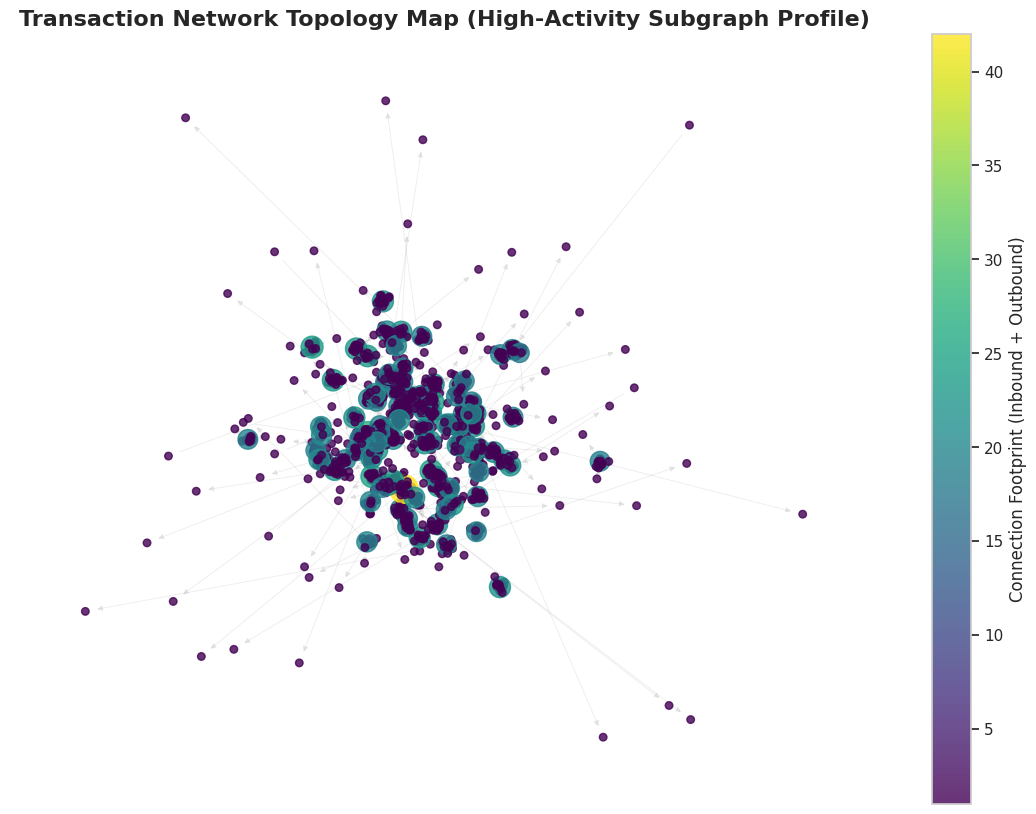

In [14]:
import matplotlib.pyplot as plt

print("Extracting high-importance core network components for high-speed layout rendering...")

# 1. Filter out isolated nodes or low-activity consumer accounts for visual optimization
# We sort nodes by total connections (degree) and pick the top 100 focal points
total_degrees = {node: in_degrees.get(node, 0) + out_degrees.get(node, 0) for node in G.nodes()}
sorted_nodes = sorted(total_degrees.items(), key=lambda x: x[1], reverse=True)
top_hub_nodes = [node for node, deg in sorted_nodes[:100]]

# 2. Gather the focal hub accounts and their immediate transaction partners
visual_nodes = set(top_hub_nodes)
for node in top_hub_nodes:
    visual_nodes.update(G.successors(node))
    visual_nodes.update(G.predecessors(node))

# Create a focused subgraph mapping only these relevant entities
G_sub = G.subgraph(visual_nodes)

print(f"Rendering optimized macro network layout with {G_sub.number_of_nodes()} active entities...")
fig, ax = plt.subplots(figsize=(14, 10)) # Create figure and axes explicitly

# 3. Compute the spring layout on the subset (runs instantly)
pos_global = nx.spring_layout(G_sub, k=0.15, seed=42)

# Extract visualization metrics matching the subset
sub_degrees = [in_degrees.get(n, 0) + out_degrees.get(n, 0) for n in G_sub.nodes()]
max_deg_sub = max(sub_degrees) if sub_degrees else 1
scaled_sizes = [20 + (deg / max_deg_sub) * 400 for deg in sub_degrees]

# 4. Generate the final plot layers
nodes_scatter = nx.draw_networkx_nodes(
    G_sub,
    pos_global,
    node_size=scaled_sizes,
    node_color=sub_degrees,
    cmap='viridis',
    alpha=0.8,
    ax=ax # Draw on the explicit axes
)

nx.draw_networkx_edges(
    G_sub,
    pos_global,
    alpha=0.15,
    edge_color='gray',
    width=0.6,
    arrows=True,
    arrowsize=8,
    ax=ax # Draw on the explicit axes
)

ax.set_title("Transaction Network Topology Map (High-Activity Subgraph Profile)", fontsize=16, fontweight='bold')
plt.colorbar(nodes_scatter, ax=ax, label='Connection Footprint (Inbound + Outbound)') # Pass the mappable and axes
ax.axis('off')
plt.show()

In [15]:
# Create a DataFrame to consolidate node information for easier analysis
node_analysis_df = pd.DataFrame({
    'account_id': list(G.nodes()),
    'in_degree': [in_degrees.get(node, 0) for node in G.nodes()],
    'out_degree': [out_degrees.get(node, 0) for node in G.nodes()],
    'total_degree': [total_degrees.get(node, 0) for node in G.nodes()],
    'betweenness_centrality': [betweenness.get(node, 0) for node in G.nodes()]
})

# Merge with account KYC data to add risk_grade and acct_type
node_analysis_df = node_analysis_df.merge(
    accounts_df[['account_id', 'risk_grade', 'acct_type']],
    on='account_id',
    how='left'
)

# Display the top accounts by total degree
print("Top 10 Accounts by Total Degree:")
display(node_analysis_df.sort_values(by='total_degree', ascending=False).head(10))

# Display the top accounts by betweenness centrality
print("\nTop 10 Accounts by Betweenness Centrality:")
display(node_analysis_df.sort_values(by='betweenness_centrality', ascending=False).head(10))

# Display accounts with high risk grade and high total degree
print("\nHigh-Risk Accounts (RISK-HIGH) by Total Degree:")
display(node_analysis_df[node_analysis_df['risk_grade'] == 'RISK-HIGH'].sort_values(by='total_degree', ascending=False).head(10))

Top 10 Accounts by Total Degree:


,account_id,in_degree,out_degree,total_degree,betweenness_centrality,risk_grade,acct_type
210,6086421020,21,21,42,0.0,RISK-LOW,LOAN
1264,283280424,20,7,27,0.0,RISK-MED,SAVINGS
2601,22513864,0,25,25,0.0,RISK-LOW,NOSTRO
6451,8976725341,0,25,25,0.0,RISK-HIGH,LOAN
2836,2670254274,21,3,24,0.0,RISK-LOW,REMIT
163,2365007895,0,24,24,0.0,RISK-MED,NOSTRO
4678,8353228494,19,5,24,0.0,RISK-HIGH,FIXED
7394,9683990807,21,3,24,0.0,RISK-LOW,REMIT
6833,7080357663,20,3,23,0.0,RISK-LOW,SAVINGS
7205,464342049,20,3,23,0.0,RISK-LOW,FIXED



Top 10 Accounts by Betweenness Centrality:


,account_id,in_degree,out_degree,total_degree,betweenness_centrality,risk_grade,acct_type
7409,4595501668,5,6,11,9.183158e-07,RISK-LOW,REMIT
11703,9856997398,1,5,6,7.652632e-07,RISK-LOW,FIXED
9717,8251429562,1,4,5,6.122105e-07,RISK-HIGH,CURRENT
4082,3519006611,11,3,14,4.591579e-07,RISK-MED,CURRENT
7333,4702676308,13,3,16,4.591579e-07,RISK-MED,REMIT
11868,6034997194,19,2,21,3.061053e-07,RISK-HIGH,REMIT
22299,900000000161,1,1,2,3.061053e-07,RISK-HIGH,FIXED
15728,6444220418,18,2,20,3.061053e-07,RISK-HIGH,NOSTRO
751,3443340463,5,3,8,3.061053e-07,RISK-MED,SAVINGS
16325,4891593500,4,2,6,3.061053e-07,RISK-LOW,CURRENT



High-Risk Accounts (RISK-HIGH) by Total Degree:


,account_id,in_degree,out_degree,total_degree,betweenness_centrality,risk_grade,acct_type
6451,8976725341,0,25,25,0.0,RISK-HIGH,LOAN
4678,8353228494,19,5,24,0.0,RISK-HIGH,FIXED
5508,15297964,0,23,23,0.0,RISK-HIGH,REMIT
3480,382301928,0,23,23,0.0,RISK-HIGH,NOSTRO
2170,5748154530,18,5,23,0.0,RISK-HIGH,FIXED
14733,4255313773,21,2,23,0.0,RISK-HIGH,SAVINGS
10668,1871309831,18,4,22,0.0,RISK-HIGH,FIXED
1508,461573471,0,22,22,0.0,RISK-HIGH,LOAN
962,3529992395,19,3,22,0.0,RISK-HIGH,NOSTRO
20337,5251195293,20,1,21,0.0,RISK-HIGH,FIXED


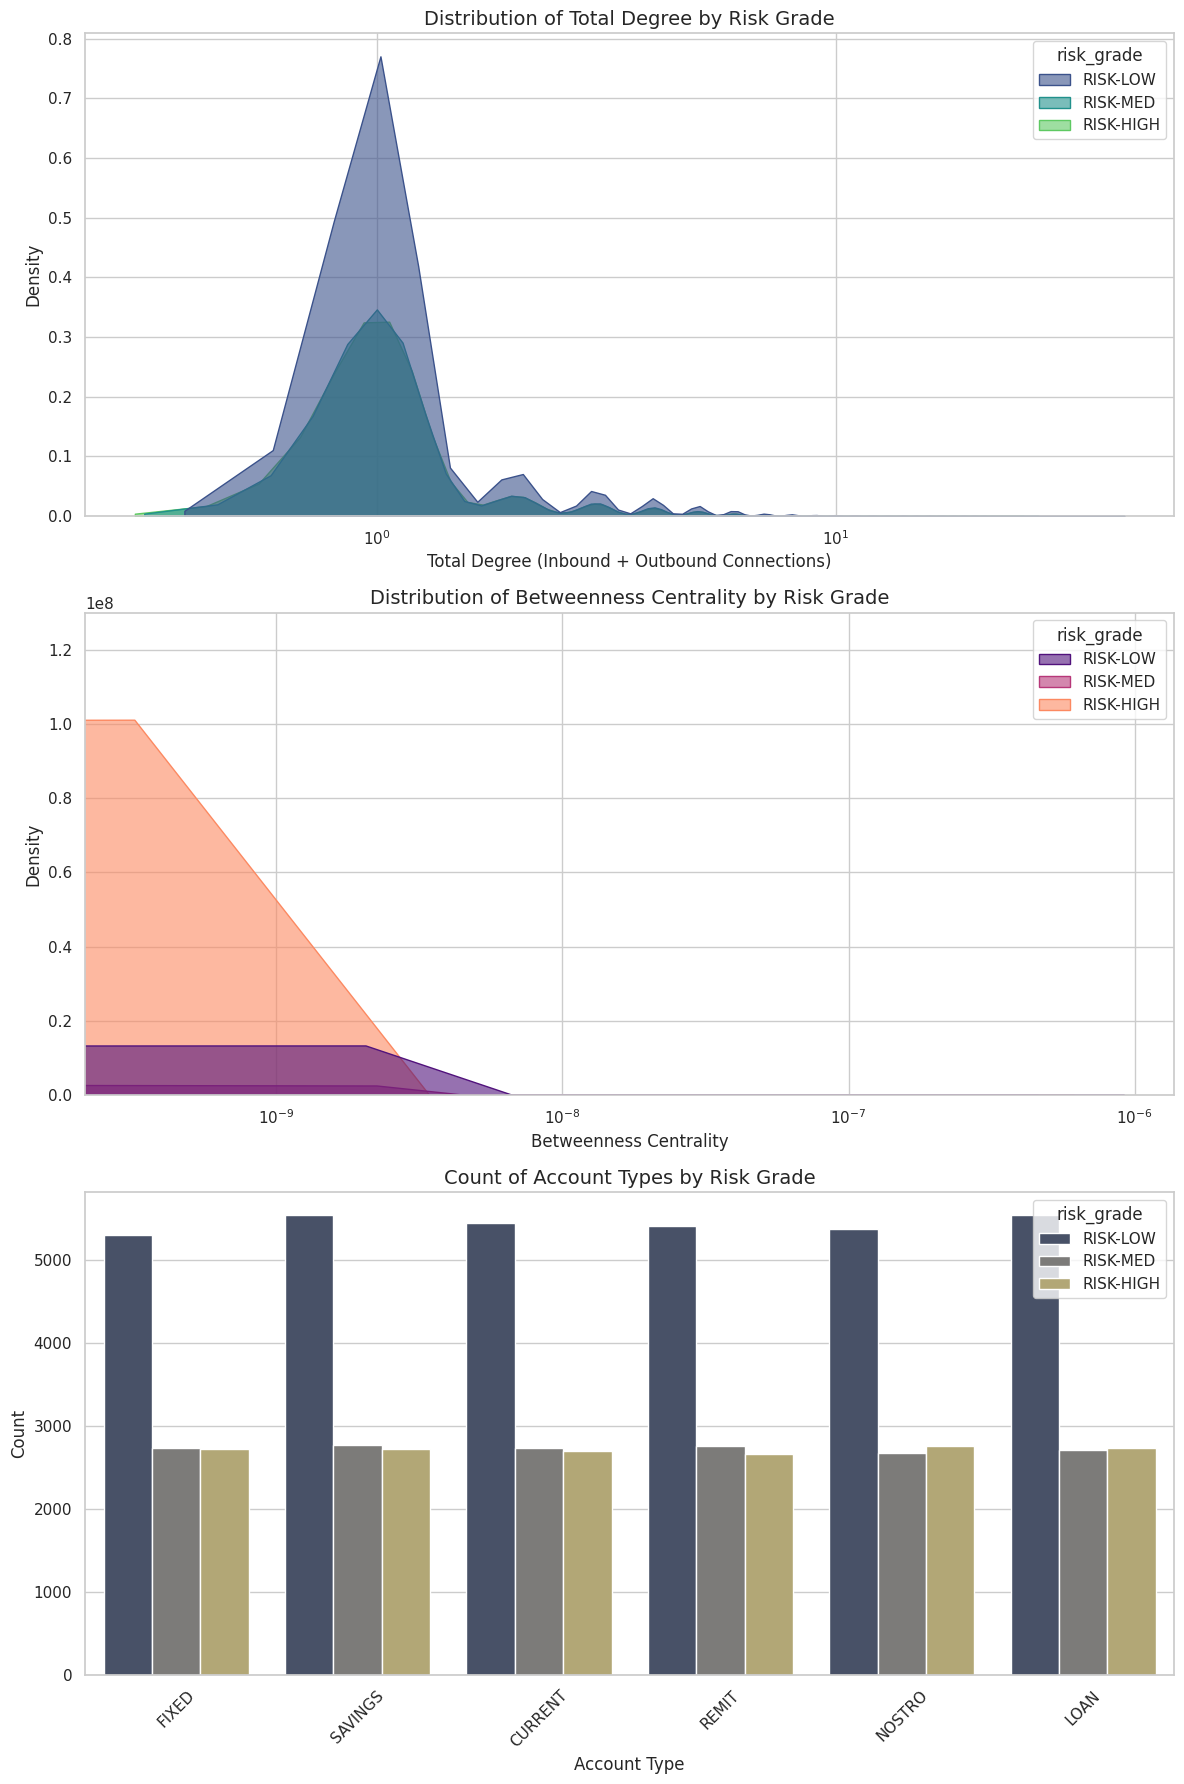

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot 1: Distribution of Total Degree by Risk Grade
sns.kdeplot(data=node_analysis_df, x='total_degree', hue='risk_grade', fill=True, palette='viridis', alpha=0.6, ax=axes[0])
axes[0].set_title('Distribution of Total Degree by Risk Grade', fontsize=14)
axes[0].set_xlabel('Total Degree (Inbound + Outbound Connections)')
axes[0].set_ylabel('Density')
axes[0].set_xscale('log')

# Plot 2: Distribution of Betweenness Centrality by Risk Grade
sns.kdeplot(data=node_analysis_df, x='betweenness_centrality', hue='risk_grade', fill=True, palette='magma', alpha=0.6, ax=axes[1])
axes[1].set_title('Distribution of Betweenness Centrality by Risk Grade', fontsize=14)
axes[1].set_xlabel('Betweenness Centrality')
axes[1].set_ylabel('Density')
axes[1].set_xscale('log')

# Plot 3: Count of Account Types by Risk Grade
sns.countplot(data=node_analysis_df, x='acct_type', hue='risk_grade', palette='cividis', ax=axes[2])
axes[2].set_title('Count of Account Types by Risk Grade', fontsize=14)
axes[2].set_xlabel('Account Type')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
print("Step 3: Isolating specific subgraphs based on financial crime typologies...")

node_profiles = []

# Statistical baselines to discover extreme behavioral anomalies
high_out_degree_threshold = np.percentile(list(out_degrees.values()), 95)
high_in_degree_threshold = np.percentile(list(in_degrees.values()), 95)
high_betweenness_threshold = np.percentile(list(betweenness.values()), 95)

for node in G.nodes():
    in_deg = in_degrees.get(node, 0)
    out_deg = out_degrees.get(node, 0)
    bet_cen = betweenness.get(node, 0)
    in_loop = 1 if node in cycle_nodes else 0

    # Initializing structural risk typologies
    is_smurfing_source = 0
    is_smurfing_collector = 0
    is_layering_hub = 0

    # Heuristic definitions matching physical structures
    if out_deg > high_out_degree_threshold and in_deg <= 1:
        is_smurfing_source = 1
    if in_deg > high_in_degree_threshold and out_deg <= 1:
        is_smurfing_collector = 1
    if bet_cen > high_betweenness_threshold and in_deg >= 2 and out_deg >= 2:
        is_layering_hub = 1

    node_profiles.append({
        'account_id': node,
        'in_degree': in_deg,
        'out_degree': out_deg,
        'betweenness_centrality': bet_cen,
        'circular_flow_participant': in_loop,
        'typology_smurfing_source': is_smurfing_source,
        'typology_smurfing_collector': is_smurfing_collector,
        'typology_layering_hub': is_layering_hub
    })

typology_df = pd.DataFrame(node_profiles)

Step 3: Isolating specific subgraphs based on financial crime typologies...


In [18]:
print("Step 4: Compiling score engine and generating plain-text audit trails...")

# Combining topology with existing node records
scoring_df = typology_df.merge(accounts_df, on='account_id', how='inner')

# Mathematically composite score formula
scoring_df['structural_risk_score'] = (
    (scoring_df['betweenness_centrality'] * 40) +
    (scoring_df['circular_flow_participant'] * 30) +
    (scoring_df['typology_layering_hub'] * 15) +
    (scoring_df['typology_smurfing_source'] * 10) +
    (scoring_df['typology_smurfing_collector'] * 10)
)

# Applying context inflation factor based on KYC records
scoring_df.loc[scoring_df['risk_grade'] == 'RISK-HIGH', 'structural_risk_score'] += 5

# Scaling scores precisely between 0 and 100
max_observed = scoring_df['structural_risk_score'].max()
if max_observed > 0:
    scoring_df['structural_risk_score'] = (scoring_df['structural_risk_score'] / max_observed) * 100

# Sorting from high to low risk to fulfill the ranked requirement
final_ranked_list = scoring_df.sort_values(by='structural_risk_score', ascending=False).reset_index(drop=True)

# Defining explicit natural language reasonings based on structural configurations
def construct_justification(row):
    flags = []
    if row['circular_flow_participant'] == 1:
        flags.append("Participates in a closed directed cycle path (Circular Flow Typology) where funds loop back to origins.")
    if row['typology_layering_hub'] == 1:
        flags.append(f"Acts as a critical transaction bridge/middleman node (Layering Typology) with a betweenness centrality score of {row['betweenness_centrality']:.4f}.")
    if row['typology_smurfing_source'] == 1:
        flags.append(f"Exhibits a structural fan-out pattern (Smurfing Source) splitting asset flows into {row['out_degree']} unique outbound directions with zero inbound history.")
    if row['typology_smurfing_collector'] == 1:
        flags.append(f"Exhibits a structural fan-in aggregation pattern (Smurfing Collector) pooling assets from {row['in_degree']} disparate accounts.")

    if not flags:
        if row['betweenness_centrality'] > 0:
            flags.append("Elevated pass-through transaction volume relative to standard node neighborhoods.")
        else:
            flags.append("Standard operational profile with minor network variations.")

    return " | ".join(flags)

final_ranked_list['supporting_explanation'] = final_ranked_list.apply(construct_justification, axis=1)

# Formatting and isolating output table attributes for delivery
delivery_cols = ['account_id', 'structural_risk_score', 'risk_grade', 'acct_type', 'in_degree', 'out_degree', 'supporting_explanation']
submission_ready_output = final_ranked_list[delivery_cols]

# Saving file to directory
submission_ready_output.to_csv('final_ranked_suspicious_accounts.csv', index=False)
print("System execution complete. Pipeline output written to 'final_ranked_suspicious_accounts.csv'.")

Step 4: Compiling score engine and generating plain-text audit trails...
System execution complete. Pipeline output written to 'final_ranked_suspicious_accounts.csv'.


Extracting high-risk subgraphs


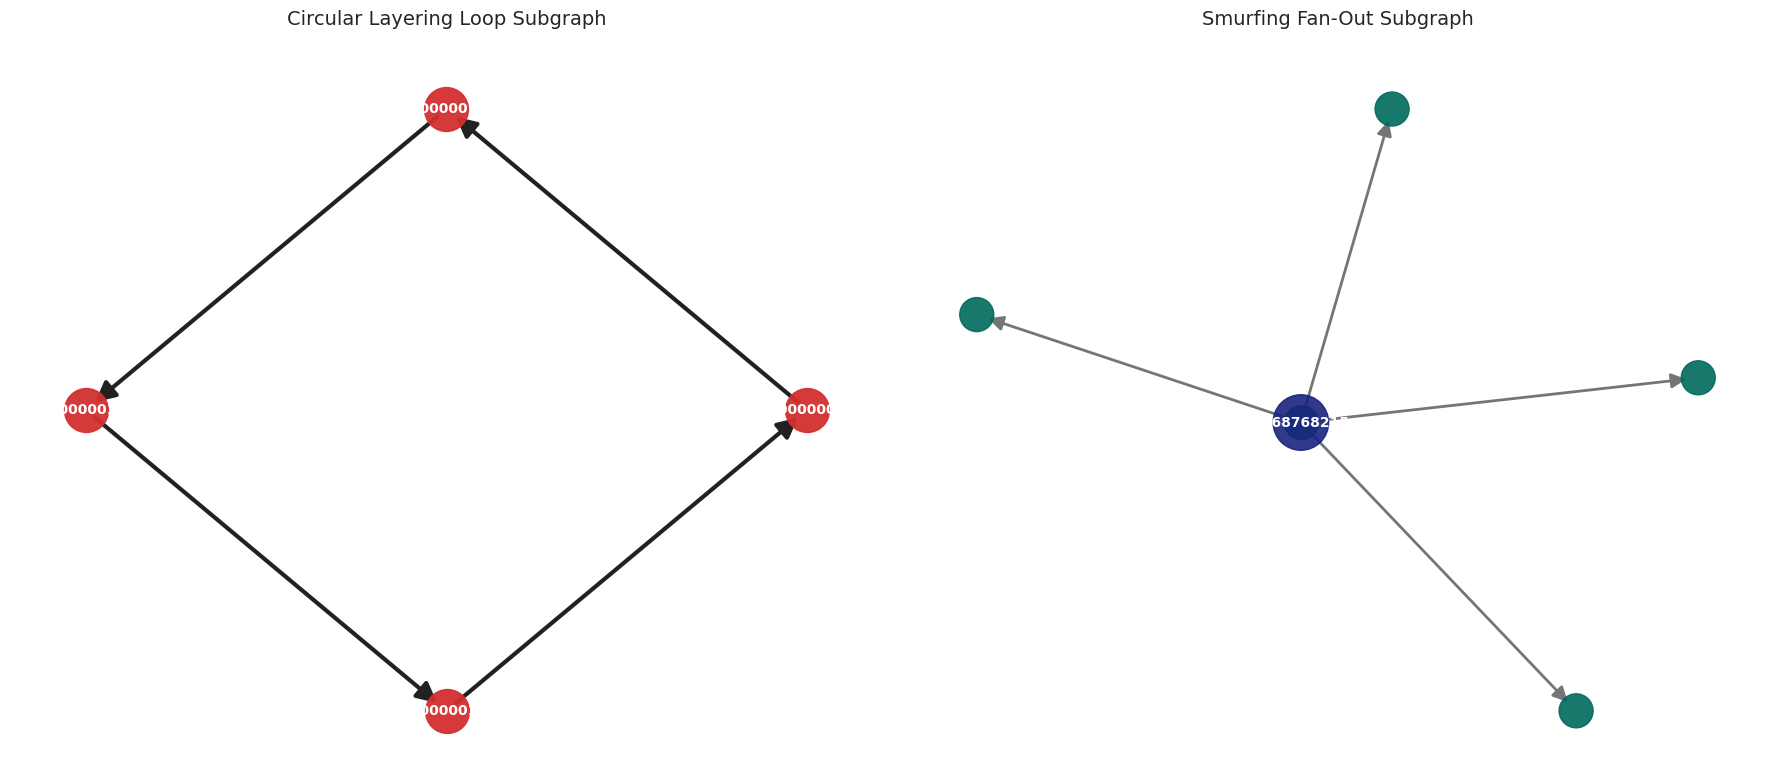

In [19]:
import matplotlib.pyplot as plt

print("Extracting high-risk subgraphs")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Subplot 1: Circular Layering Loop
if len(detected_cycles) > 0:
    sample_cycle = list(detected_cycles[0])
    subgraph_loop = G.subgraph(sample_cycle)
    pos_loop = nx.circular_layout(subgraph_loop)

    nx.draw_networkx_nodes(subgraph_loop, pos_loop, ax=axes[0], node_color='#d32f2f', node_size=1000, alpha=0.95)
    nx.draw_networkx_edges(subgraph_loop, pos_loop, ax=axes[0], edge_color='#212121', width=3, arrowsize=30)
    nx.draw_networkx_labels(subgraph_loop, pos_loop, ax=axes[0], font_size=10, font_color='white', font_weight='bold')

    axes[0].set_title("Circular Layering Loop Subgraph", fontsize=14, pad=15)
    axes[0].axis('off')
else:
    axes[0].axis('off')

# Subplot 2: Smurfing Fan-Out Structure
smurfing_sources = final_ranked_list[final_ranked_list['typology_smurfing_source'] == 1]

if not smurfing_sources.empty:
    top_smurfer = smurfing_sources.iloc[0]['account_id']
    all_successors = list(G.successors(top_smurfer))

    # Limit to 6 target nodes to keep clear visual separation
    display_neighbors = all_successors[:6]
    subgraph_nodes = [top_smurfer] + display_neighbors
    subgraph_smurf = G.subgraph(subgraph_nodes)

    # Increase k parameter to force nodes further apart
    pos_smurf = nx.spring_layout(subgraph_smurf, k=0.8, seed=42)

    node_colors = ['#1a237e' if node == top_smurfer else '#00695c' for node in subgraph_smurf.nodes()]
    node_sizes = [1600 if node == top_smurfer else 600 for node in subgraph_smurf.nodes()]

    nx.draw_networkx_nodes(subgraph_smurf, pos_smurf, ax=axes[1], node_color=node_colors, node_size=node_sizes, alpha=0.9)
    nx.draw_networkx_edges(subgraph_smurf, pos_smurf, ax=axes[1], edge_color='#757575', width=2, arrowsize=22)

    # Label only the central node of interest
    labels = {node: str(node) if node == top_smurfer else '' for node in subgraph_smurf.nodes()}
    nx.draw_networkx_labels(subgraph_smurf, pos_smurf, ax=axes[1], labels=labels, font_size=10, font_color='white', font_weight='bold')

    axes[1].set_title("Smurfing Fan-Out Subgraph", fontsize=14, pad=15)
    axes[1].axis('off')
else:
    axes[1].axis('off')

plt.tight_layout()
plt.show()

In [20]:
# View the top 10 anomalies isolated by the network system
pd.set_option('display.max_colwidth', None)
submission_ready_output.head(10)

,account_id,structural_risk_score,risk_grade,acct_type,in_degree,out_degree,supporting_explanation
0,4595501668,100.000000,RISK-LOW,REMIT,5,6,Participates in a closed directed cycle path (Circular Flow Typology) where funds loop back to origins. | Acts as a critical transaction bridge/middleman node (Layering Typology) with a betweenness centrality score of 0.0000.
1,3443340463,99.999946,RISK-MED,SAVINGS,5,3,Participates in a closed directed cycle path (Circular Flow Typology) where funds loop back to origins. | Acts as a critical transaction bridge/middleman node (Layering Typology) with a betweenness centrality score of 0.0000.
2,5442384483,99.999918,RISK-HIGH,SAVINGS,5,1,Participates in a closed directed cycle path (Circular Flow Typology) where funds loop back to origins. | Exhibits a structural fan-in aggregation pattern (Smurfing Collector) pooling assets from 5 disparate accounts.
3,8868768215,99.999918,RISK-HIGH,LOAN,1,5,Participates in a closed directed cycle path (Circular Flow Typology) where funds loop back to origins. | Exhibits a structural fan-out pattern (Smurfing Source) splitting asset flows into 5 unique outbound directions with zero inbound history.
4,7391227991,88.888816,RISK-LOW,LOAN,4,1,Participates in a closed directed cycle path (Circular Flow Typology) where funds loop back to origins. | Exhibits a structural fan-in aggregation pattern (Smurfing Collector) pooling assets from 4 disparate accounts.
5,9559039761,88.888816,RISK-MED,CURRENT,1,6,Participates in a closed directed cycle path (Circular Flow Typology) where funds loop back to origins. | Exhibits a structural fan-out pattern (Smurfing Source) splitting asset flows into 6 unique outbound directions with zero inbound history.
6,671762334,88.888816,RISK-MED,LOAN,4,1,Participates in a closed directed cycle path (Circular Flow Typology) where funds loop back to origins. | Exhibits a structural fan-in aggregation pattern (Smurfing Collector) pooling assets from 4 disparate accounts.
7,5126476939,88.888816,RISK-LOW,LOAN,1,7,Participates in a closed directed cycle path (Circular Flow Typology) where funds loop back to origins. | Exhibits a structural fan-out pattern (Smurfing Source) splitting asset flows into 7 unique outbound directions with zero inbound history.
8,9066985971,88.888816,RISK-MED,NOSTRO,4,1,Participates in a closed directed cycle path (Circular Flow Typology) where funds loop back to origins. | Exhibits a structural fan-in aggregation pattern (Smurfing Collector) pooling assets from 4 disparate accounts.
9,8759116670,88.888816,RISK-LOW,CURRENT,1,6,Participates in a closed directed cycle path (Circular Flow Typology) where funds loop back to origins. | Exhibits a structural fan-out pattern (Smurfing Source) splitting asset flows into 6 unique outbound directions with zero inbound history.


Generating Model Behavioral Feature Distributions


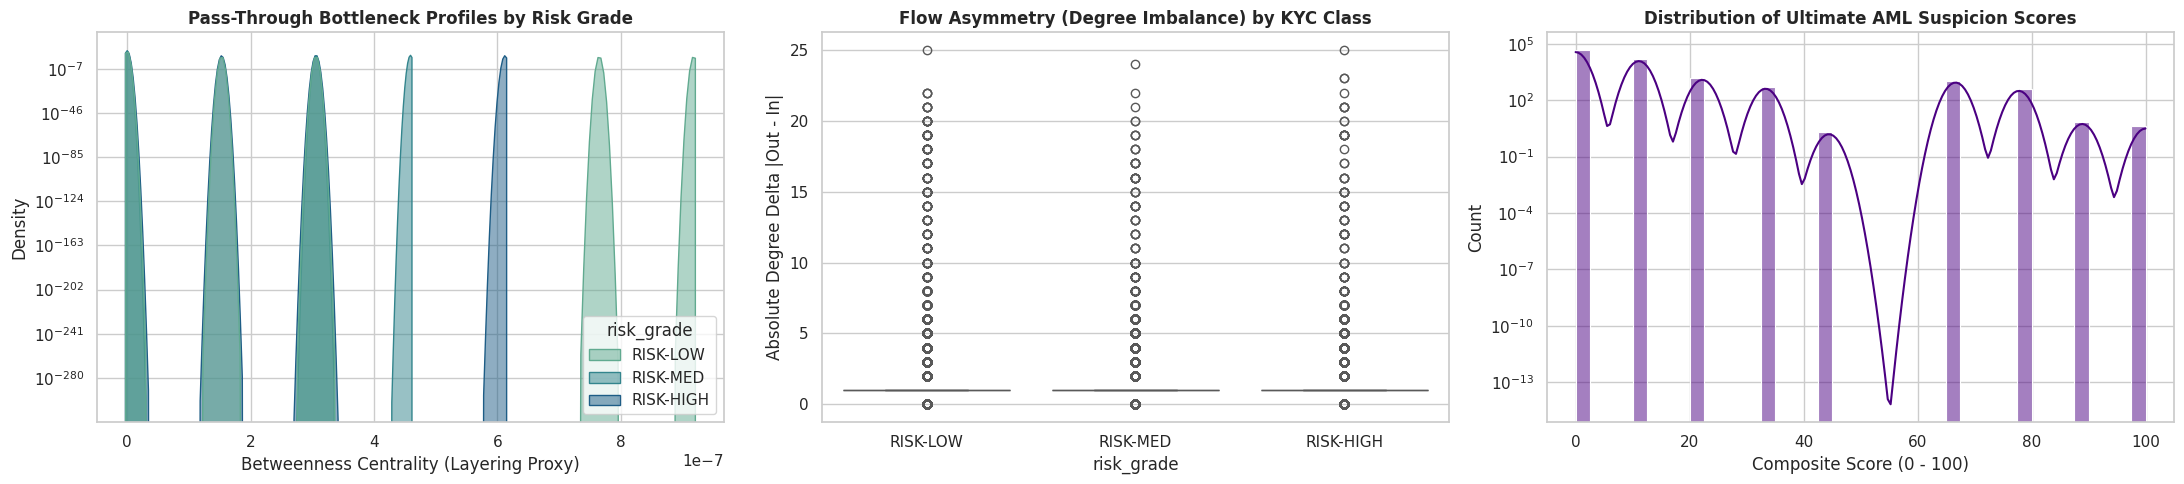

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating Model Behavioral Feature Distributions")

# Setting a professional visual aesthetic
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# Plot 1: Betweenness distribution across high risk vs standard accounts
sns.kdeplot(data=final_ranked_list, x='betweenness_centrality', hue='risk_grade',
            fill=True, common_norm=False, palette='crest', alpha=0.5, ax=axes[0])
axes[0].set_title('Pass-Through Bottleneck Profiles by Risk Grade', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Betweenness Centrality (Layering Proxy)')
axes[0].set_yscale('log') # Log scale because anomalies are extreme outliers

# Plot 2: Structural Degree Discrepancies (Outbound vs Inbound Imbalances)
final_ranked_list['degree_imbalance'] = (final_ranked_list['out_degree'] - final_ranked_list['in_degree']).abs()
sns.boxplot(data=final_ranked_list, x='risk_grade', y='degree_imbalance', palette='Set2', ax=axes[1])
axes[1].set_title('Flow Asymmetry (Degree Imbalance) by KYC Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Absolute Degree Delta |Out - In|')

# Plot 3: Distribution of Final Composite Anomaly Scores
sns.histplot(data=final_ranked_list, x='structural_risk_score', bins=40, color='indigo', kde=True, ax=axes[2])
axes[2].set_title('Distribution of Ultimate AML Suspicion Scores', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Composite Score (0 - 100)')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

In [22]:
def generate_forensic_dossier(target_account_id):
    """
    Generates a full operational compliance dossier for any flagged account in the network.
    """
    # Isolating the target node record
    target_record = final_ranked_list[final_ranked_list['account_id'] == target_account_id]

    if target_record.empty:
        print(f"Account ID {target_account_id} not found in the transaction graph.")
        return

    row = target_record.iloc[0]

    print("="*80)
    print(f"      FORENSIC NETWORK INTELLIGENCE DOSSIER: ACCOUNT {target_account_id}")
    print("="*80)
    print(f"  [METRIC PROFILE]")
    print(f"  • Final Suspicion Rating    : {row['structural_risk_score']:.2f} / 100")
    print(f"  • Registered KYC Risk Grade: {row['risk_grade']}")
    print(f"  • Entity Account Classification Type: {row['acct_type']}")
    print(f"  • Active Network Neighbors  : Inbound Senders: {row['in_degree']} | Outbound Receivers: {row['out_degree']}")
    print(f"  • Network Bridge Multiplier : {row['betweenness_centrality']:.6f}")
    print("-"*80)
    print(f"  [AUTOMATED COMPLIANCE AUDIT TRAIL / JUSTIFICATION]")
    print(f"  {row['supporting_explanation']}")
    print("-"*80)
    print(f"  [IMMEDIATE UPSTREAM SENDERS (Top 5 Sources)]")
    upstream = [edge[0] for edge in G.in_edges(target_account_id)]
    print(f"  {upstream[:5] if upstream else 'None Detected'}")
    print(f"  [IMMEDIATE DOWNSTREAM BENEFICIARIES (Top 5 Destinations)]")
    downstream = [edge[1] for edge in G.out_edges(target_account_id)]
    print(f"  {downstream[:5] if downstream else 'None Detected'}")
    print("="*80)

# TEST RUN: Automatically lookup the #1 most suspicious account discovered by your system
top_suspect_id = final_ranked_list.iloc[0]['account_id']
generate_forensic_dossier(top_suspect_id)

      FORENSIC NETWORK INTELLIGENCE DOSSIER: ACCOUNT 4595501668
  [METRIC PROFILE]
  • Final Suspicion Rating    : 100.00 / 100
  • Registered KYC Risk Grade: RISK-LOW
  • Entity Account Classification Type: REMIT
  • Active Network Neighbors  : Inbound Senders: 5 | Outbound Receivers: 6
  • Network Bridge Multiplier : 0.000001
--------------------------------------------------------------------------------
  [AUTOMATED COMPLIANCE AUDIT TRAIL / JUSTIFICATION]
  Participates in a closed directed cycle path (Circular Flow Typology) where funds loop back to origins. | Acts as a critical transaction bridge/middleman node (Layering Typology) with a betweenness centrality score of 0.0000.
--------------------------------------------------------------------------------
  [IMMEDIATE UPSTREAM SENDERS (Top 5 Sources)]
  [np.float64(1552381575.0), np.float64(2153903615.0), np.float64(8484459691.0), np.float64(8559231933.0), np.float64(9057324231.0)]
  [IMMEDIATE DOWNSTREAM BENEFICIARIES (Top 5 De

Rendering targeted Forensic Ego-Network Neighborhood Spotlight...


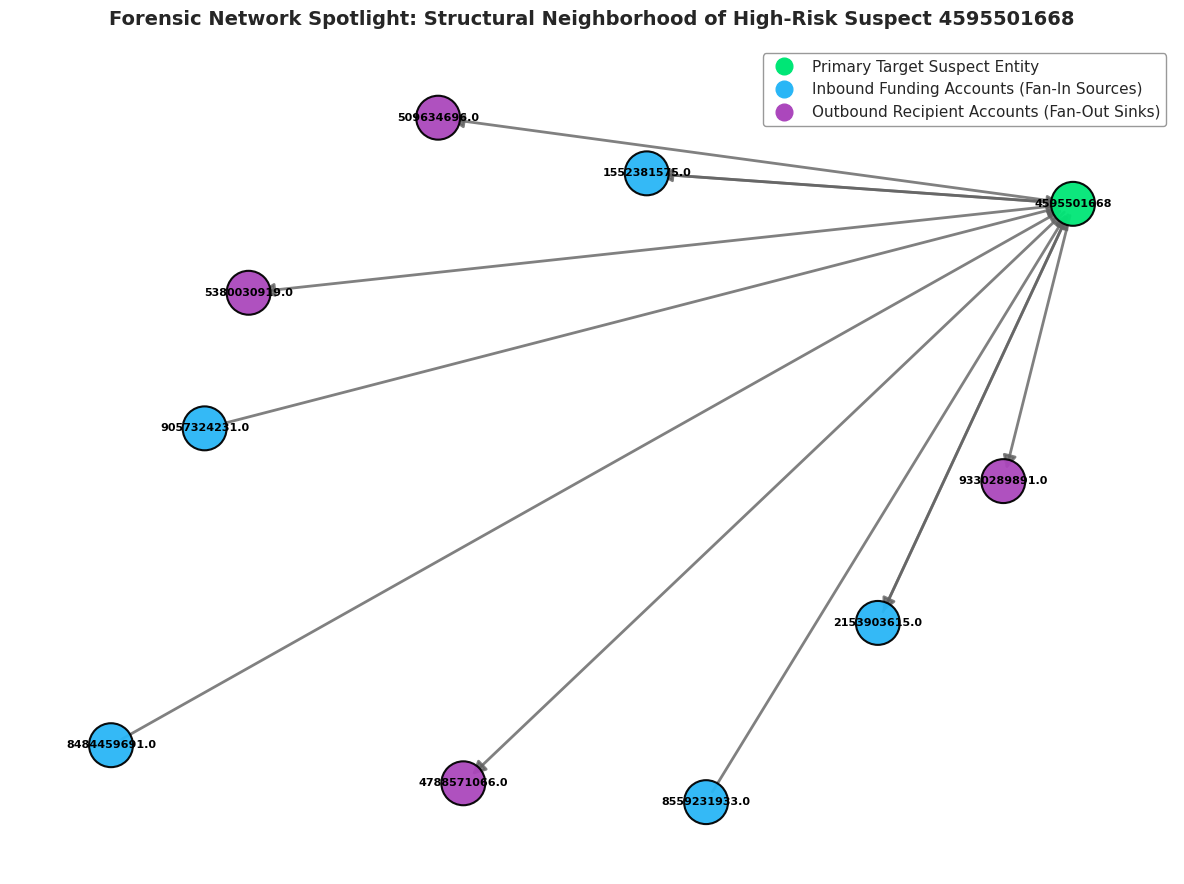

In [23]:
print("Rendering targeted Forensic Ego-Network Neighborhood Spotlight...")

# Extracting the top suspect and their local network neighborhood boundary
primary_target = final_ranked_list.iloc[0]['account_id']
neighbors = list(G.successors(primary_target)) + list(G.predecessors(primary_target))
neighborhood_nodes = [primary_target] + list(set(neighbors))[:20] # Bound to 20 nodes for premium visualization layout

# Constructing localized ego subgraph
G_ego = G.subgraph(neighborhood_nodes)

plt.figure(figsize=(12, 9))
pos_ego = nx.kamada_kawai_layout(G_ego) # Premium layout engine for structural alignment

# Establishing distinct node coloring matrix
ego_colors = []
for node in G_ego.nodes():
    if node == primary_target:
        ego_colors.append('#00e676') # Neon Green for the target central suspect
    elif G.has_edge(node, primary_target):
        ego_colors.append('#29b6f6') # Sky Blue for upstream feeding accounts
    else:
        ego_colors.append('#ab47bc') # Purple for downstream recipient accounts

# Drawing the specialized network layers
nx.draw_networkx_nodes(G_ego, pos_ego, node_size=1000, node_color=ego_colors, edgecolors='black', linewidths=1.5, alpha=0.95)
nx.draw_networkx_edges(G_ego, pos_ego, width=2, edge_color='#616161', alpha=0.8, arrowsize=20)

# Applying clear numeric indicators
nx.draw_networkx_labels(G_ego, pos_ego, font_size=8, font_color='black', font_weight='bold')

# Constructing custom legend mapping for the judging panel presentation slide
plt.plot([], [], color='#00e676', marker='o', linestyle='None', markersize=12, label='Primary Target Suspect Entity')
plt.plot([], [], color='#29b6f6', marker='o', linestyle='None', markersize=12, label='Inbound Funding Accounts (Fan-In Sources)')
plt.plot([], [], color='#ab47bc', marker='o', linestyle='None', markersize=12, label='Outbound Recipient Accounts (Fan-Out Sinks)')

plt.title(f"Forensic Network Spotlight: Structural Neighborhood of High-Risk Suspect {primary_target}", fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='gray')
plt.axis('off')
plt.tight_layout()
plt.show()